In [1]:
# 1. Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 2. Reading dataset
# Make sure to update the path to point to your new dataset
df = pd.read_csv("C:\Data\Customer-Churn-Records (1).csv")

print("Dataset Overview:")
print(df.head())

Dataset Overview:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1                   2   DIAMOND   


In [3]:
# 3. Data Preprocessing
# Dropping irrelevant identifier columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [4]:
# 4. Label Encoding
# We must encode all categorical text columns, including the new 'Card Type' column
le = LabelEncoder()
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])
df['Card Type'] = le.fit_transform(df['Card Type'])

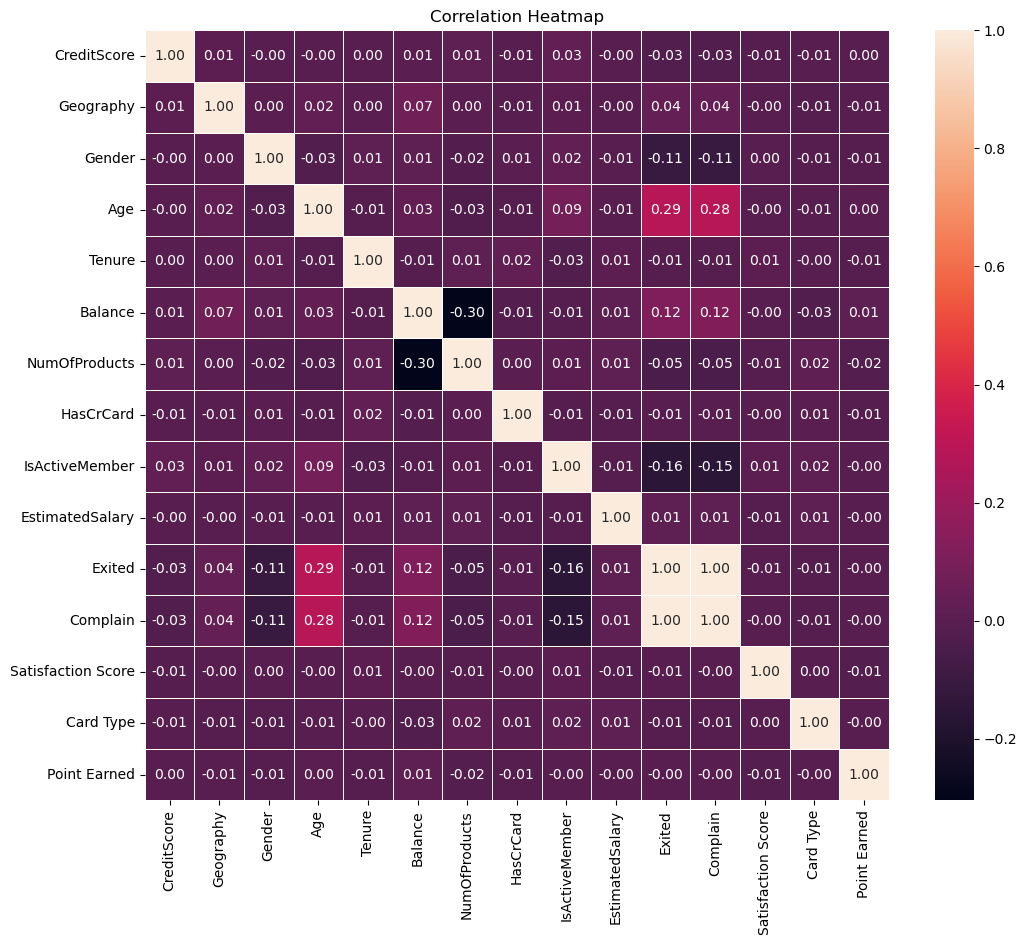

In [5]:
# Heatmap to show correlation
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [6]:
# 5. Splitting X and y
# FIXED: Dropping 'Complain' to prevent Data Leakage!
X = df.drop(['Exited', 'Complain'], axis=1)
y = df['Exited']

In [7]:
# 6. Normalisation
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# 7. Splitting data to train data and test data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=1)

In [10]:
# 8. Model Building (Original Data)
print("\n--- EVALUATING ORIGINAL DATA ---")

models = {
    'KNN': KNeighborsClassifier(),
    'NAIVE BAYES': GaussianNB(),
    'SVC': SVC(),
    'DECISION TREE': DecisionTreeClassifier(),
    'RANDOM FOREST': RandomForestClassifier(),
    'ADABOOST': AdaBoostClassifier()
}

original_accuracies = []

for name, model in models.items():
    print(f'\n********** {name} *********')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    original_accuracies.append(acc * 100)
    print(classification_report(y_test, y_pred))


--- EVALUATING ORIGINAL DATA ---

********** KNN *********
              precision    recall  f1-score   support

           0       0.81      0.95      0.88      2373
           1       0.49      0.18      0.27       627

    accuracy                           0.79      3000
   macro avg       0.65      0.57      0.57      3000
weighted avg       0.75      0.79      0.75      3000


********** NAIVE BAYES *********
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      2373
           1       0.83      0.22      0.35       627

    accuracy                           0.83      3000
   macro avg       0.83      0.60      0.63      3000
weighted avg       0.83      0.83      0.79      3000


********** SVC *********
              precision    recall  f1-score   support

           0       0.83      0.99      0.90      2373
           1       0.86      0.25      0.38       627

    accuracy                           0.83      3000
   macro

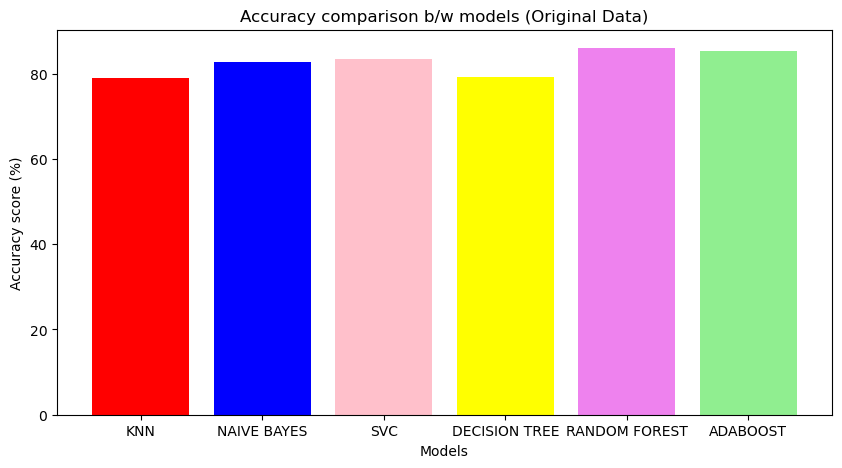

In [11]:
# Plotting Original Accuracies
plt.figure(figsize=(10,5))
plt.title('Accuracy comparison b/w models (Original Data)')
plt.xlabel('Models')
plt.ylabel('Accuracy score (%)')
plt.bar(models.keys(), original_accuracies, color=['red','blue','pink','yellow','violet','lightgreen'])
plt.show()

In [12]:
# 9. Over Sampling (SMOTE)
print("\n--- EVALUATING OVER SAMPLING (SMOTE) ---")
from imblearn.over_sampling import SMOTE
oversample = SMOTE(random_state=1)
X_os, y_os = oversample.fit_resample(X, y)


--- EVALUATING OVER SAMPLING (SMOTE) ---


In [13]:
# 9. Over Sampling (SMOTE)
print("\n--- EVALUATING OVER SAMPLING (SMOTE) ---")
from imblearn.over_sampling import SMOTE
oversample = SMOTE(random_state=1)
X_os, y_os = oversample.fit_resample(X, y)

X_train_os, X_test_os, y_train_os, y_test_os = train_test_split(X_os, y_os, test_size=0.3, random_state=1)
X_train_os = scaler.fit_transform(X_train_os)
X_test_os = scaler.transform(X_test_os)

os_accuracies = []
for name, model in models.items():
    print(f'\n********** {name} *********')
    model.fit(X_train_os, y_train_os)
    y_pred_os = model.predict(X_test_os)
    acc = accuracy_score(y_test_os, y_pred_os)
    os_accuracies.append(acc * 100)
    print(classification_report(y_test_os, y_pred_os))



--- EVALUATING OVER SAMPLING (SMOTE) ---

********** KNN *********
              precision    recall  f1-score   support

           0       0.82      0.77      0.79      2365
           1       0.79      0.83      0.81      2413

    accuracy                           0.80      4778
   macro avg       0.80      0.80      0.80      4778
weighted avg       0.80      0.80      0.80      4778


********** NAIVE BAYES *********
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      2365
           1       0.81      0.80      0.81      2413

    accuracy                           0.81      4778
   macro avg       0.81      0.81      0.81      4778
weighted avg       0.81      0.81      0.81      4778


********** SVC *********
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      2365
           1       0.85      0.80      0.83      2413

    accuracy                           0.83      4778


In [14]:
# 10. Under Sampling
print("\n--- EVALUATING UNDER SAMPLING ---")
from imblearn.under_sampling import RandomUnderSampler
undersample = RandomUnderSampler(random_state=1)
X_us, y_us = undersample.fit_resample(X, y)

X_train_us, X_test_us, y_train_us, y_test_us = train_test_split(X_us, y_us, test_size=0.3, random_state=1)
X_train_us = scaler.fit_transform(X_train_us)
X_test_us = scaler.transform(X_test_us)

us_accuracies = []

for name, model in models.items():
    print(f'\n********** {name} *********')
    model.fit(X_train_us, y_train_us)
    y_pred_us = model.predict(X_test_us)
    acc = accuracy_score(y_test_us, y_pred_us)
    us_accuracies.append(acc * 100)
    print(classification_report(y_test_us, y_pred_us))


--- EVALUATING UNDER SAMPLING ---

********** KNN *********
              precision    recall  f1-score   support

           0       0.65      0.67      0.66       623
           1       0.64      0.62      0.63       600

    accuracy                           0.64      1223
   macro avg       0.64      0.64      0.64      1223
weighted avg       0.64      0.64      0.64      1223


********** NAIVE BAYES *********
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       623
           1       0.72      0.72      0.72       600

    accuracy                           0.72      1223
   macro avg       0.72      0.72      0.72      1223
weighted avg       0.72      0.72      0.72      1223


********** SVC *********
              precision    recall  f1-score   support

           0       0.73      0.76      0.75       623
           1       0.74      0.71      0.73       600

    accuracy                           0.74      1223
   macr

In [15]:
# 11. Final Comparison Table
df_final = pd.DataFrame({
    'Model': list(models.keys()),
    'Accuracy (Original)': original_accuracies,
    'Accuracy (Oversampling)': os_accuracies,
    'Accuracy (Undersampling)': us_accuracies
})
print("\n--- FINAL COMPARISON TABLE ---")
print(df_final.round(2))


--- FINAL COMPARISON TABLE ---
           Model  Accuracy (Original)  Accuracy (Oversampling)  \
0            KNN                79.00                    80.12   
1    NAIVE BAYES                82.80                    80.56   
2            SVC                83.43                    82.90   
3  DECISION TREE                79.27                    78.95   
4  RANDOM FOREST                86.03                    85.83   
5       ADABOOST                85.43                    83.07   

   Accuracy (Undersampling)  
0                     64.43  
1                     72.28  
2                     73.67  
3                     66.72  
4                     75.80  
5                     75.63  


In [16]:
#Conclusion: By comparing the performance measures of the different algorithms, the most accuratemodels for predicting customer churn are the Random Forest Classifier and the AdaBoost Classifier.


In [17]:
# 12. Predicting a new value using the Random Forest Model

# Let's invent a hypothetical customer. 
# The 13 values below correspond in order to:
# [CreditScore, Geography, Gender, Age, Tenure, Balance, NumOfProducts, HasCrCard, IsActiveMember, EstimatedSalary, Satisfaction Score, Card Type, Point Earned]

new_customer = [[850, 2, 0, 43, 2, 125510.82, 1, 1, 1, 79084.10, 3, 1, 450]]


scaled_new_customer = scaler.transform(new_customer)


rf_model = models['RANDOM FOREST']
y_new = rf_model.predict(scaled_new_customer)

print("--- NEW CUSTOMER PREDICTION ---")
if y_new == 0:
    print('Result: Continues to be a customer')
else:
    print('Result: Left the bank')

--- NEW CUSTOMER PREDICTION ---
Result: Left the bank
